<a href="https://colab.research.google.com/github/robotlover2/deeplearning26.08.10/blob/main/11_CNN_%EC%86%90%EA%B8%80%EC%94%A8%EB%B6%84%EB%A5%98_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  **기계학습-신경망(CNN) 알아보기**

1. TensorFlow에서 사용하는 CNN 메서드 탐구하기
2. 데이터셋, 데이터 정규화, 모델, loss, accuracy의 개념을 정리하기
3. VGGNet 그림을 보고 직접 만들어보기

## 이 노트북 사용법 — 학생용 실습본

이 파일은 **핵심 코드가 빈칸(`____`)으로 비워진 실습본**이다.
수업 중 강사의 설명을 들으며 빈칸을 직접 채워 넣는다.

### 진행 방법

1. 코드 셀 위쪽의 **`채울 곳`** 안내 블록을 먼저 읽는다.
2. 코드 안의 `____` 를 찾아 알맞은 값·함수 이름으로 바꾼다. 각 빈칸에는 `①` `②` 번호가 붙어 있다.
3. `Shift + Enter` 로 셀을 실행한다.

### 실행하면 이런 오류가 난다면

| 오류 메시지 | 원인 |
|---|---|
| `NameError: name '____' is not defined` | 아직 채우지 않은 빈칸이 남아 있다 |
| `SyntaxError` | 빈칸을 지우면서 괄호·따옴표를 함께 지웠다 |

> 빈칸이 아닌 부분은 이미 완성되어 있으니 고치지 않아도 된다.
> 막히면 손을 들거나 채팅으로 알리자. 정답본은 수업 후 배포된다.

# 환경설정 (학생용 실습본)
1. 코랩 상단 메뉴에서 런타임 - 런타임 유형 변경을 눌러주세요
2. 하드웨어 가속기를 None에서 GPU로 바꿔주세요.\
(코랩 프로를 결제하셨다면 GPU를 고를 수 있지만 무료로 사용하시는 분들은 T4로 고정되어 있습니다)


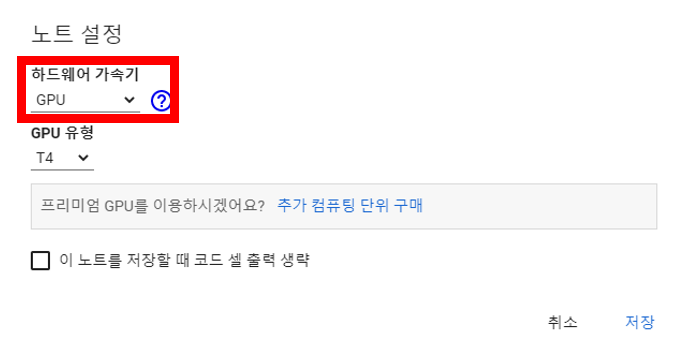

# **[숫자 이미지 분류 - MNIST를 활용한 CNN 모델 만들기]**

## 1.라이브러리 가져오기

In [1]:
# 인공지능 학습에 필요한 라이브러리 tensorflow 설치 - colab 사용시 실행하지 않아도됨
# !pip install tensorflow
# !pip install numpy
# !pip install matplotlib

In [7]:
# tensorflow 불러오기
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
print(tf.__version__)

2.20.0


## 2.데이터셋 로드 및 전처리하기

- MNIST는 0부터 9까지 숫자 손글씨로 이루어진 데이터셋으로\
28X28사이즈의 60000의 훈련 데이터와 10000개의 테스트 데이터로 구성되어 있습니다.
    - x_train.shape == (60000, 28, 28)  
    - x_test.shape == (10000, 28, 28)  
    - y_train.shape == (60000,)  
    - y_test.shape == (10000,)   

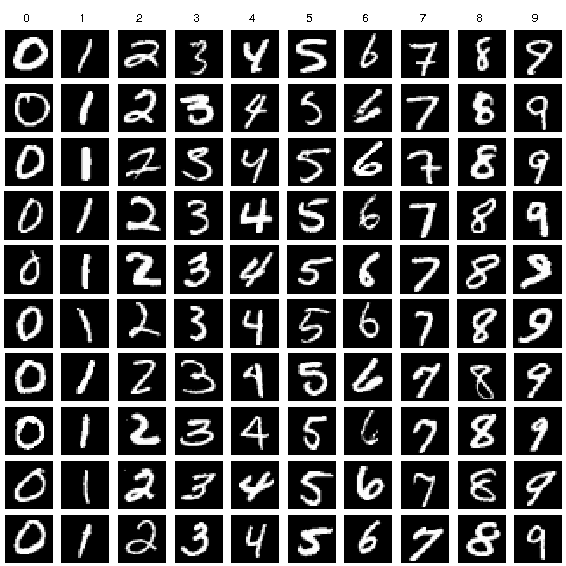

### 1)데이터셋 로드하기

In [3]:
# Keras API를 활용해서 MNIST 불러오기
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 2)데이터 확인해보기

In [4]:
np.set_printoptions(linewidth=200)
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170, 253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253, 253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253, 253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253, 205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,  90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253, 190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190, 253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35, 241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39, 148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221, 253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253, 253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253, 195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,  11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0, 136, 253, 253, 253, 212, 135, 132,  16,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0

5 입니다.


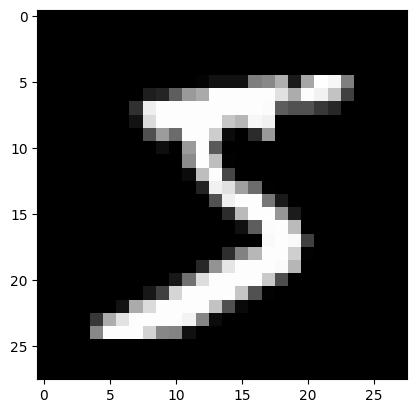

In [6]:
# 시각화해서 확인하기
plt.imshow(train_images[0],cmap='gray')#imshow이면 이미지로 보여줌
print(train_labels[0],'입니다.')

### 3)데이터 전처리 - 정규화하기
---

- 이미지를 직접 출력한 결과를 보면 0인 경우가 대부분인데 그 다음 심심치 않게 보이는 단위가 3자리수입니다. 0과 3자리수의 크기는 차이가 많이 나는데 이럴 경우 오버피팅이 될 우려가 있어\
- 데이터의 분포를 정규화시켜 scale을 줄이는 데 초점이 맞춰져있습니다.


In [7]:
print('최소값:',np.min(train_images))
print('최대값:',np.max(train_images))

최소값: 0
최대값: 255


In [8]:
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 픽셀 최댓값으로 나누어 0~1 로 정규화한다
# └───────────────────────────────────────────────────────────────

# 픽셀 값 범위를 [0, 255]에서 [0, 1]로 정규화
train_images = train_images.astype("float32") /255.0    # ① test랑 train 따로따로 받아와서 2번 정규화 해야 됌
test_images = test_images.astype("float32") / 255.0     # ①

In [9]:
print('최소값:',np.min(train_images))
print('최대값:',np.max(train_images))

최소값: 0.0
최대값: 1.0


In [10]:
train_images.shape

(60000, 28, 28)

---
## **Convolution Neural Network 알아보기**
걍 무시해도 됌
- [tf.keras.layers.Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D)

- Convolution Neural Network를 구성하고 있는 매개변수(Arguments)는 filters부터 bias_contraint까지 총 16개로 구성되어 있습니다.

- **filters** : 출력되는 결과의 차원수를 의미합니다.
    -  filter가 영향을 준 부분은 Tuple의 마지막 부분인 channel파트입니다\
즉 filter를 몇개 주는지에 따라서 channel수가 바뀌게 되고 이는 차원수가 바뀌는 것을 의미합니다.

In [ ]:
input_shape = (4, 28, 28, 3)
x = tf.random.normal(input_shape)
y = tf.keras.layers.Conv2D(filters = 2, kernel_size = 3, activation = 'relu')(x)
print(y.shape)

(4, 26, 26, 2)


In [ ]:
input_shape = (4, 28, 28, 3)
x = tf.random.normal(input_shape)
y = tf.keras.layers.Conv2D(filters = 2, kernel_size = 2, activation = 'relu')(x)
print(y.shape)

(4, 27, 27, 2)


- **kernel_size** : kernel_size가 위에 있는 코드는 3, 아래에 있는 코드는 2로 되어 있습니다. 그래서 output이 바뀐 파트는 Tuple의 2번째, 3번째에 영향을 줍니다.

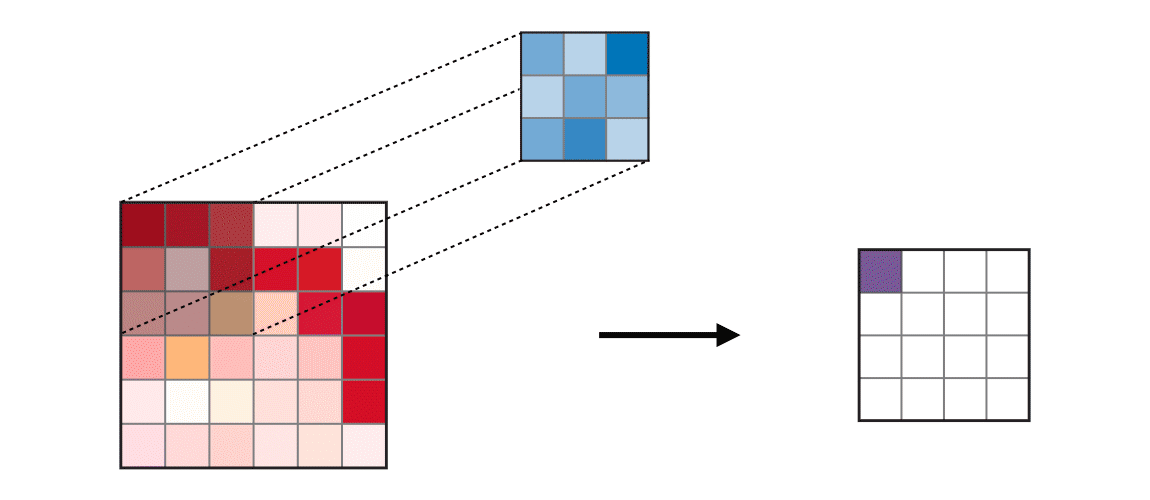

위에 있는 gif를 보게 되면 빨간색 6x6 이미지를 3x3 filter를 이용해 convolution 연산이 진행되고 결과값은 보라색 이미지인 4x4이미지입니다.

해당 방식을 수학적으로 표현하면 다음과 같이 표현가능합니다.

$$ output = input - filter + 1 $$

- **strides**\ : strides는 filter 이동을 1개씩 가는 것이 아니라 n개씩 가도록 설정하는 매개변수입니다.

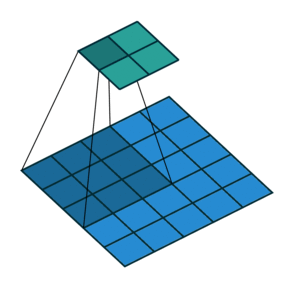


위에 있는 그림을 보게 되면 5x5 이미지를 3x3 filter가 2개씩 가도록 설정되어 있습니다.\
해당 설정을 하지 않았다면 output의 크기는 3x3이 되어야 하지만 stride가 설정되면서 2x2로 출력값이 나오게 되었습니다. 해당 내용도 코드로도 확인해보도록 하겠습니다.

In [ ]:
input_shape = (4, 28, 28, 3)
x = tf.random.normal(input_shape)
y = tf.keras.layers.Conv2D(filters = 2, kernel_size = 3, activation = 'relu')(x)
print(y.shape)

(4, 26, 26, 2)


In [ ]:
input_shape = (4, 28, 28, 3)
x = tf.random.normal(input_shape)
y = tf.keras.layers.Conv2D(filters = 2, kernel_size = 3, strides = 2, activation = 'relu')(x)
print(y.shape)

(4, 13, 13, 2)


stride가 적용되면 실제 output의 크기는 step만큼 나누어져서 계산됩니다. \
그렇기에 stride가 적용된 output_shape은 다음과 같습니다.

$$
output = \frac{(input-filter)}{stride} + 1
$$


- **padding**
    - padding을 하는 이유는 filter는 가운데 파트는 몇번씩 거치면서 계산되지만 끝에 있는 edge부분은 한번밖에 계산되지 않습니다. 그렇기에 padding을 주어서 edge를 잘 볼 수 있게 하는 장치입니다.

    - TensorFlow의 경우 padding은 '자동'으로 적용하며 'valid'는 적용하지 않은 것이며 'same'은 padding이 적용된 상황입니다.

In [ ]:
input_shape = (4, 28, 28, 3)
x = tf.random.normal(input_shape)
y = tf.keras.layers.Conv2D(filters = 2, kernel_size = 3, activation = 'relu')(x)
print(y.shape)

(4, 26, 26, 2)


In [ ]:
input_shape = (4, 28, 28, 3)
x = tf.random.normal(input_shape)
y = tf.keras.layers.Conv2D(filters = 2, kernel_size = 3, activation = 'relu', padding = 'same')(x)
print(y.shape)

(4, 28, 28, 2)


padding이 적용되었을 때 Output shape은 다음과 같이 계산됩니다.

$$
output = \frac{(input - filter + 2*padding)}{stride}+1
$$


- **input_shape** : 처음 layer를 쌓을 떄 설정해주는 값이며
- **activation** : convolution 연산 이후 활성화함수를 고르는 매개변수입니다.
---

## 3.모델 구성하기

- 신경망 모델을 만들려면 모델의 층을 구성한 다음 모델을 컴파일합니다.

In [12]:
# ┌─ 채울 곳 ───────────────────────
# ① Input Shape 입력
# ② 첫 합성곱층이 학습할 필터 개수 : 16
# ③ 은닉층 활성화 함수 (문자열)
# ④ 풀링 크기 : (2, 2) — 가로세로를 절반으로 줄인다
# ⑤ 2차원 특징맵을 1줄로 펴는 층 이름
# ⑥ 출력층 뉴런 수와 활성화 함수
# └─────────────────────────────

from tensorflow import keras

# 모델 아키텍처 정의
model=keras.models.Sequential()
model.add(keras.layers.Input(shape=(28,28,1))) # ①CNN일때는 회색조로 되어있어서 28,28,1
model.add(keras.layers.Conv2D(16, (3,3), activation='relu'))   # ② ③  3x3 짜리 filter 16개를 사용함

model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))   # ④ 합성곱으로 인해서 늘어난 데이터 줄이기
# Convolution layer를 추가하고 output 차원수를 32, filter 사이즈를 3, 활성화함수를 relu로 설정해주세요
model.add(keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'))

# 다시한번 Maxpooling2D layer를 추가해주세요
model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

# 모델의 차원을 줄여주세요 (참고자료 : https://keras.io/api/layers/reshaping_layers/flatten/)
model.add(keras.layers.Flatten())   #  ⑤ Dense 층 사용 하려고 데이터 구조를 1차원으로 만들어줌
# Dense layer를 쌓고 output unit을 32로 넣고 활성화함수를 relu로 설정해주세요. (참고자료 : https://keras.io/api/layers/core_layers/dense/)
model.add(keras.layers.Dense(32, activation='relu'))
# Dense Layer를 쌓되 output unit을 우리의 분류할 품목 숫자대로 넣어주세요.
model.add(keras.layers.Dense(10, activation='softmax'))   # ⑥


In [13]:
# 모델 확인
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,026 (164.16 KB)

 Trainable params: 42,026 (164.16 KB)

 Non-trainable params: 0 (0.00 B)

## 4.모델 컴파일하기

In [14]:
# ┌─ 채울 곳 ──────────────────────────────────
# ① 정답이 정수 라벨인 다중 분류용 손실 클래스 이름
#    (문자열 'sparse_categorical_crossentropy' 의 클래스 버전)
# └────────────────────────────────────────

# 모델 컴파일. 손실 함수, 옵티마이저, 메트릭 정의
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),   # ① 다중 분류라서 DNN의 categroical 사용
              metrics=['accuracy'])

## 5.모델 학습하기

In [15]:
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 반복 학습 횟수 : 10
# └───────────────────────────────────────────────────────────────

# 훈련 데이터를 이용해 모델 학습
history = model.fit(
    train_images,
    train_labels,
    epochs=10,            # ① # 전체 학습 데이터를 10번 반복
    batch_size=32,         # 한 번에 32개씩 학습
    validation_split=0.2,  # 학습 데이터의 20%를 검증용으로 사용
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9367 - loss: 0.2045 - val_accuracy: 0.9746 - val_loss: 0.0840
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9791 - loss: 0.0668 - val_accuracy: 0.9797 - val_loss: 0.0665
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9846 - loss: 0.0495 - val_accuracy: 0.9826 - val_loss: 0.0578
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9881 - loss: 0.0385 - val_accuracy: 0.9855 - val_loss: 0.0483
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9907 - loss: 0.0312 - val_accuracy: 0.9856 - val_loss: 0.0518
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9922 - loss: 0.0251 - val_accuracy: 0.9853 - val_loss: 0.0531
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9931 - loss: 0.0212 - val_accuracy: 0.9868 - val_loss: 0.0507
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9947 - loss: 0.0163 

## 6.모델 평가하기

In [16]:
# 테스트 데이터로 모델 평가. 손실과 정확도 출력
test_loss, test_acc = model.evaluate(
    test_images, test_labels, verbose=2
) # ①evaluate로 모델 평가해줌

print(f'테스트 Loss: {test_loss:.4f}')
print(f'테스트 정확도: {test_acc * 100:.2f}%')

313/313 - 2s - 6ms/step - accuracy: 0.9899 - loss: 0.0337
테스트 Loss: 0.0337
테스트 정확도: 98.99%


## 7.모델 예측하고 결과 시각화하기

In [18]:
# 모델 예측
predictions = model.predict(test_images) # ①test_img를 가지고 다시 예측함

# 첫 번째 데이터 예측 결과
print("예측값:", np.argmax(predictions[0])) # ②argmax 로 가장 predict이 가장 큰 값의 index를 뽑아 오면 됌
print("실제값:", test_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
예측값: 7
실제값: 7


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


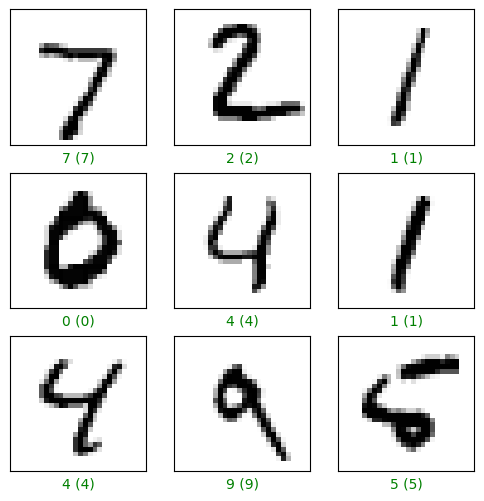

In [19]:
# 예측 결과 시각화
predictions = model.predict(test_images)
num_rows = 3
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, num_cols, i+1)
    plt.imshow(test_images[i], cmap=plt.cm.binary)
    plt.xticks([])
    plt.yticks([])
    predicted_label = np.argmax(predictions[i])
    true_label = test_labels[i]
    if predicted_label == true_label:
        color = 'green'
    else:
        color = 'red'
    plt.xlabel("{} ({})".format(predicted_label, true_label), color=color)
plt.show()

In [29]:
import pandas as pd
predicted_labels = np.argmax(predictions, axis=1) # 0~9중 하나 예측한 값 들어있는 열
confidence_scores = np.max(predictions, axis=1) # 그중 가장 큰값

# 판다스 데이터프레임 생성
df_predictions = pd.DataFrame({
    'Index': np.arange(len(test_labels)),
    'True_Label': test_labels,
    'Predicted_Label': predicted_labels,
    'Confidence': np.round(confidence_scores, 4),
    'Is_Correct': (test_labels == predicted_labels)
})

# CSV 파일로 저장
csv_filename = 'test_predictions.csv'
df_predictions.to_csv(csv_filename, index=False, encoding='utf-8-sig')
print(f"✅ 예측 결과가 '{csv_filename}' 파일로 저장되었습니다.\n")

✅ 예측 결과가 'test_predictions.csv' 파일로 저장되었습니다.



# **[Fashin MNIST를 활용한 CNN 모델 만들고 학습해보기]**  
---

In [8]:
# [실습 1] Fashion MNIST를 직접 불러오자!
# 참고자료 : https://keras.io/api/datasets/fashion_mnist/
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_fashion_images, train_fashion_labels), (test_fashion_images, test_fashion_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
#label이 숫자로 되어 있으니 영어로 된 리스트를 드리겠습니다.
label_list = ['T-shirt','Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle_boot']

label_list :  Ankle_boot


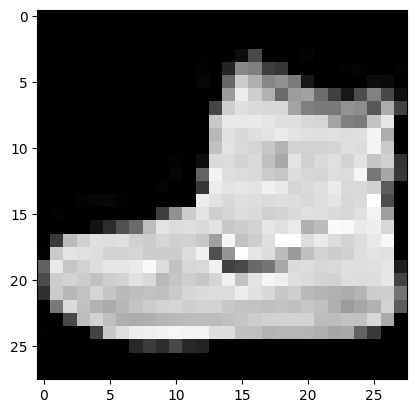

In [10]:
# 불러온 데이터를 시각화해주세요.
plt.imshow(train_fashion_images[0], cmap='gray')
print('label_list : ', label_list[train_fashion_labels[0]])

In [11]:
# [실습 2] 픽셀 값 범위를 [0, 255]에서 [0, 1]로 정규화를 진행해주세요!
train_fashion_images =train_fashion_images.astype("float32") /255.0
test_fashion_images  =test_fashion_images.astype("float32") /255.0

- model.summary()를 진행했을때 아래와 같은 내용으로 나오게끔 만들어주세요!
- VGGNet 모델

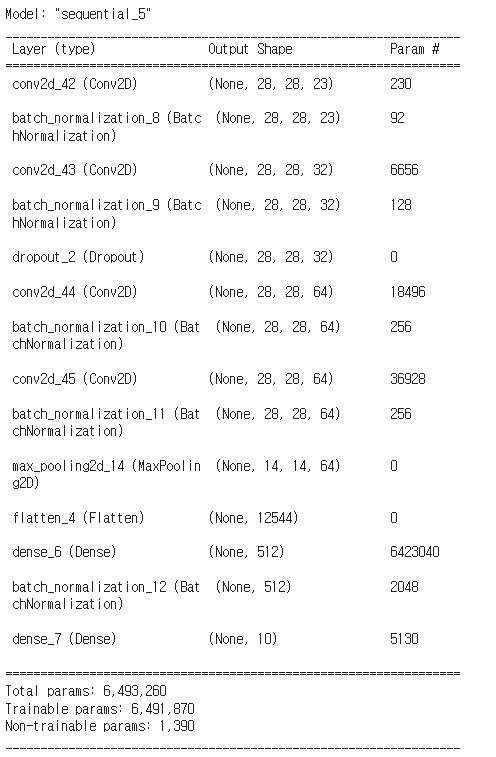

In [12]:
import tensorflow as tf
from tensorflow import keras

# 1. 모델 아키텍처 정의 (이미지 summary와 완전 일치)
model = keras.models.Sequential([
    # 입력 및 첫 번째 Conv 블록 (filters=23, padding='same')
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Conv2D(23, (3, 3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),

    # 두 번째 Conv 블록 (filters=32) + Dropout
    keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.25),

    # 세 번째 Conv 블록 (filters=64)
    keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),

    # 네 번째 Conv 블록 (filters=64) + MaxPooling (14x14로 축소)
    keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # 분류기 블록 (Flatten -> Dense 512 -> BatchNorm -> Dense 10)
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation='softmax')
])

# 2. Summary 출력 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 23)     │           230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 23)     │            92 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,493,260 (24.77 MB)

 Trainable params: 6,491,870 (24.76 MB)

 Non-trainable params: 1,390 (5.43 KB)

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 23)     │           230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 23)     │            92 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,493,260 (24.77 MB)

 Trainable params: 6,491,870 (24.76 MB)

 Non-trainable params: 1,390 (5.43 KB)

In [16]:
# [실습 4] 모델을 컴파일하고 학습시켜주세요.
# 옵티마이저는 'adam' / loss는 SparseCategoricalCrossentropy / 평가지표는 정확도 / epoch은 5
# 모델 컴파일. 손실 함수, 옵티마이저, 메트릭 정의
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),   # ① 다중 분류라서 DNN의 categroical 사용
              metrics=['accuracy'])
# 훈련 데이터를 이용해 모델 학습
history = model.fit(
    train_fashion_images,
    train_fashion_labels,
    epochs=5,            # ① # 전체 학습 데이터를 10번 반복
    batch_size=32,         # 한 번에 32개씩 학습
    validation_split=0.2,  # 학습 데이터의 20%를 검증용으로 사용
    verbose=1
)



Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.8678 - loss: 0.3758 - val_accuracy: 0.8576 - val_loss: 0.3941
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9112 - loss: 0.2468 - val_accuracy: 0.9112 - val_loss: 0.2502
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9233 - loss: 0.2085 - val_accuracy: 0.9156 - val_loss: 0.2449
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9340 - loss: 0.1815 - val_accuracy: 0.9112 - val_loss: 0.3049
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9488 - loss: 0.1416 - val_accuracy: 0.9214 - val_loss: 0.2338


In [17]:
# 테스트 데이터로 모델 평가. 손실과 정확도 출력
test_loss, test_acc = model.evaluate(test_fashion_images, test_fashion_labels, verbose=2)
print('테스트 loss:', test_loss, '테스트 정확도:', test_acc)

313/313 - 3s - 11ms/step - accuracy: 0.9160 - loss: 0.2515
테스트 loss: 0.25150737166404724 테스트 정확도: 0.9160000085830688


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


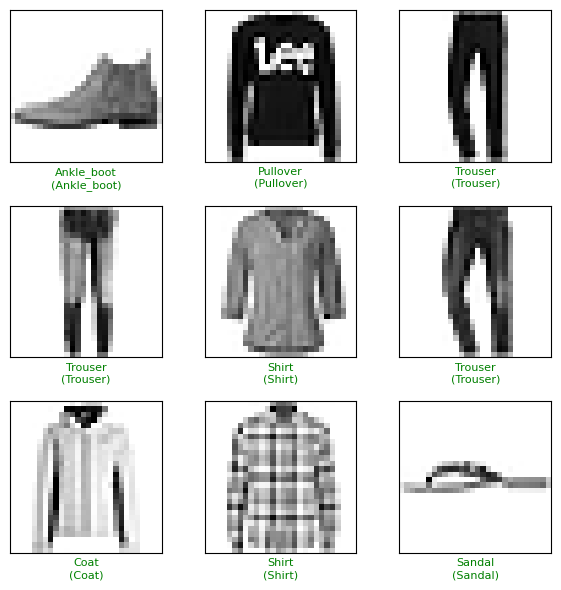

In [18]:
# 위의 내용을 바탕으로 예측 결과 시각화
predictions = model.predict(test_fashion_images)

num_rows, num_cols = 3, 3
plt.figure(figsize=(2 * num_cols, 2 * num_rows))
for i in range(num_rows * num_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(test_fashion_images[i], cmap=plt.cm.binary)
    plt.xticks([]); plt.yticks([])
    predicted_label = np.argmax(predictions[i])
    true_label = test_fashion_labels[i]
    color = 'green' if predicted_label == true_label else 'red'
    plt.xlabel(f"{label_list[predicted_label]}\n({label_list[true_label]})",
               color=color, fontsize=8)
plt.tight_layout(); plt.show()